# Vergleich: Körperpose


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, f_oneway


In [3]:
DATA_DIR = Path('../../data')
INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '11_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_body_pose.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)

# Robuste Pose-Kategorien für alte und neue Labelschemata
LEGACY_POSE_MAP = {
    'LABEL_0': 'Front',
    'LABEL_1': 'Side',
    'LABEL_2': 'Back',
    '0': 'Front',
    '1': 'Side',
    '2': 'Back',
}

def normalize_pose_label(value):
    if pd.isna(value):
        return 'Unbestimmt'
    raw = str(value).strip()
    if raw == '':
        return 'Unbestimmt'

    if raw in LEGACY_POSE_MAP:
        return LEGACY_POSE_MAP[raw]

    up = raw.upper()
    if up in LEGACY_POSE_MAP:
        return LEGACY_POSE_MAP[up]

    # Modelllabels beibehalten und nur lesbarer machen
    return raw.replace('_', ' ').strip().title()

if 'pose_orientation_readable' in df.columns:
    df['pose_orientation_readable'] = df['pose_orientation_readable'].map(normalize_pose_label)
elif 'pose_orientation' in df.columns:
    df['pose_orientation_readable'] = df['pose_orientation'].map(normalize_pose_label)
else:
    df['pose_orientation_readable'] = 'Unbestimmt'

df['pose_orientation_raw'] = df['pose_orientation'] if 'pose_orientation' in df.columns else df['pose_orientation_readable']


print(df[['influencer_type', 'pose_confidence', 'detected_pose_frames']].groupby('influencer_type').agg(['count', 'mean', 'std']))
print('Pose categories:', sorted(df['pose_orientation_readable'].dropna().unique().tolist()))



Reading ../../data/04_analysis_results/visual_features/11_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_body_pose.csv                pose_confidence                     detected_pose_frames  \                          count      mean       std                count   influencer_type                                                            ai                          250  0.638701  0.176155                  250   real                        250  0.582971  0.146903                  250                                                          mean        std  influencer_type                     ai               18.564  17.329256  real             43.156  49.010568  Pose categories: ['Calling', 'Clapping', 'Cycling', 'Dancing', 'Drinking', 'Eating', 'Fighting', 'Hugging', 'Laughing', 'Listening To Music', 'Running', 'Sitting', 'Sleeping', 'Texting', 'Using Laptop']

In [5]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


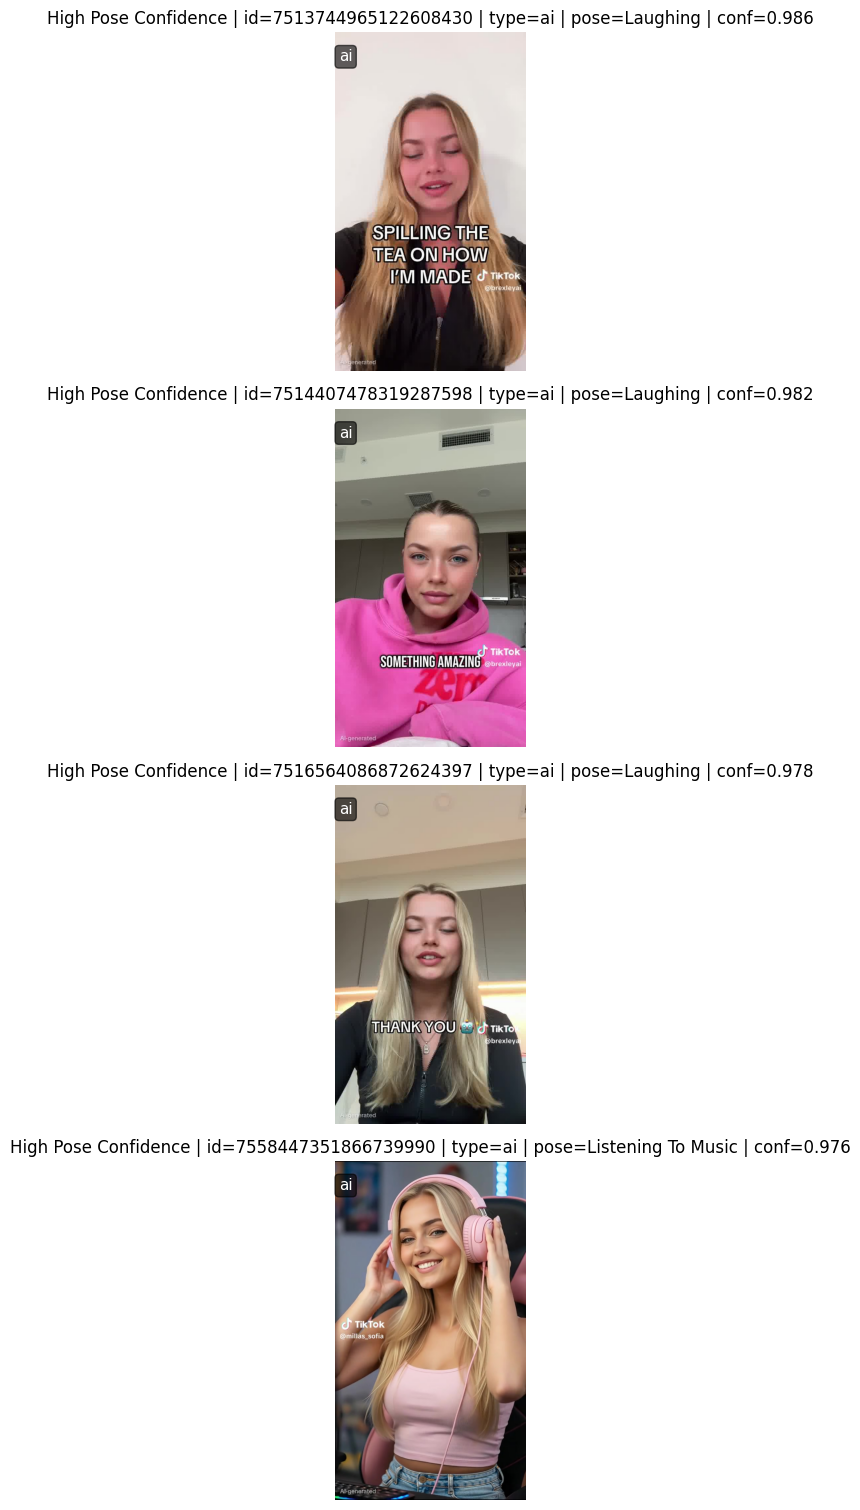

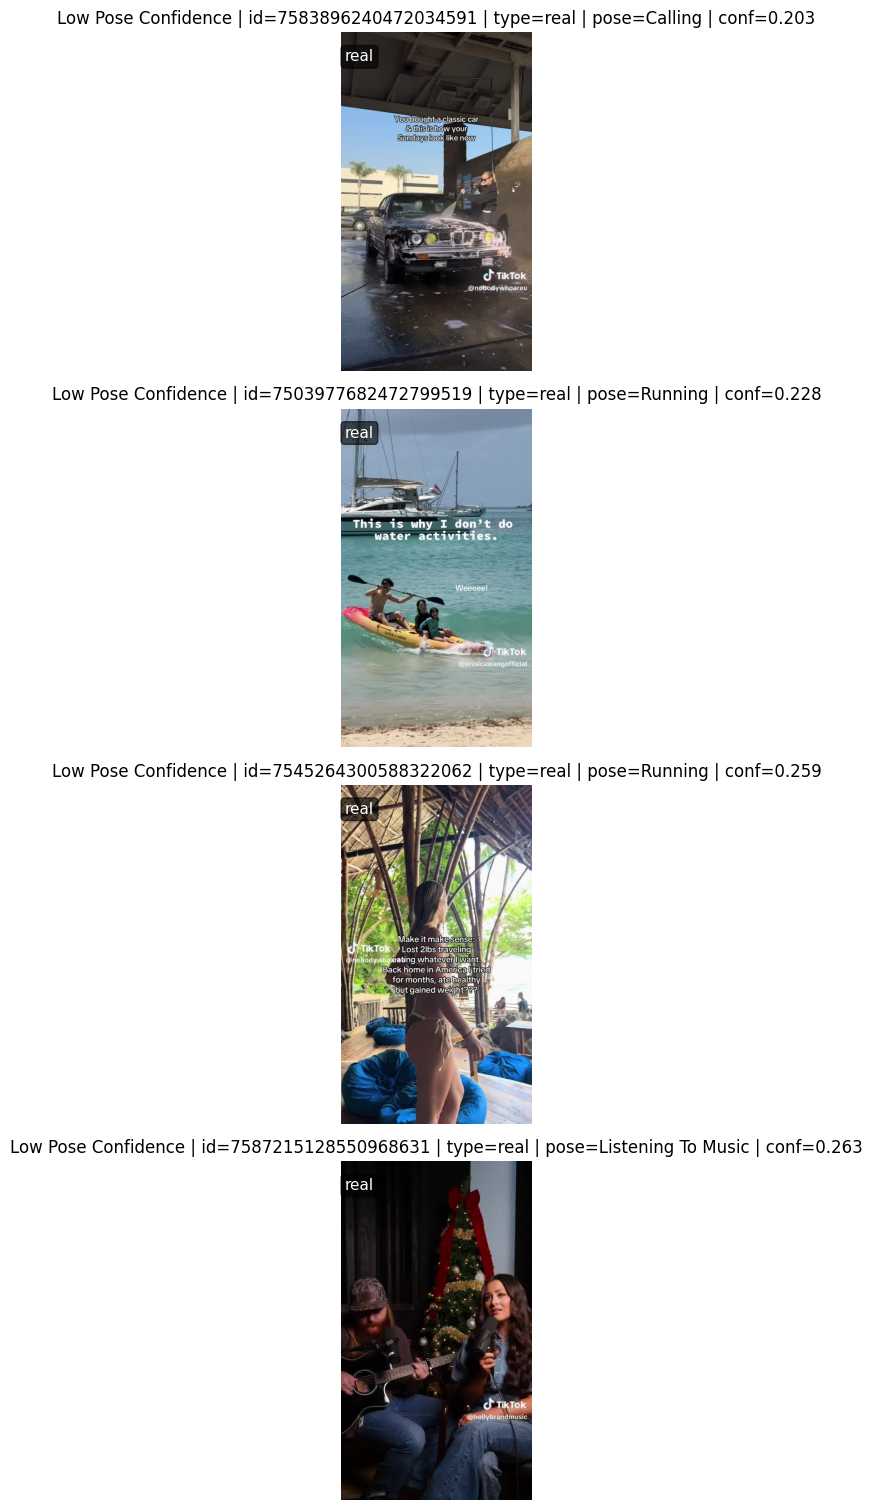

In [6]:
# Beispiele mit hoher und niedriger Pose-Konfidenz
_df = df.dropna(subset=['pose_confidence']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return
    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')
        conf = row['pose_confidence']
        pose = row.get('pose_orientation_readable', '')
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top', fontsize=11, color='white', bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(f'{title} | id={vid} | type={inf} | pose={pose} | conf={conf:.3f}')
    plt.tight_layout(); plt.show()

show_examples(pick_examples(_df.sort_values('pose_confidence', ascending=False), n=4), 'High Pose Confidence')
show_examples(pick_examples(_df.sort_values('pose_confidence', ascending=True), n=4), 'Low Pose Confidence')


In [3]:
summary = df.groupby('influencer_type')[['pose_confidence', 'detected_pose_frames']].describe().round(4)
display(summary)


pose_confidence                                          \
                          count    mean     std     min     25%     50%   
influencer_type                                                           
ai                        250.0  0.6387  0.1762  0.2702  0.5131  0.6185   
real                      250.0  0.5830  0.1469  0.2029  0.4862  0.5756   

                                detected_pose_frames                        \
                    75%     max                count    mean      std  min   
influencer_type                                                              
ai               0.7489  0.9857                250.0  18.564  17.3293  3.0   
real             0.6772  0.9694                250.0  43.156  49.0106  5.0   

                                          
                  25%   50%   75%    max  
influencer_type                           
ai                8.0  12.0  19.0  118.0  
real             12.0  25.0  56.0  326.0

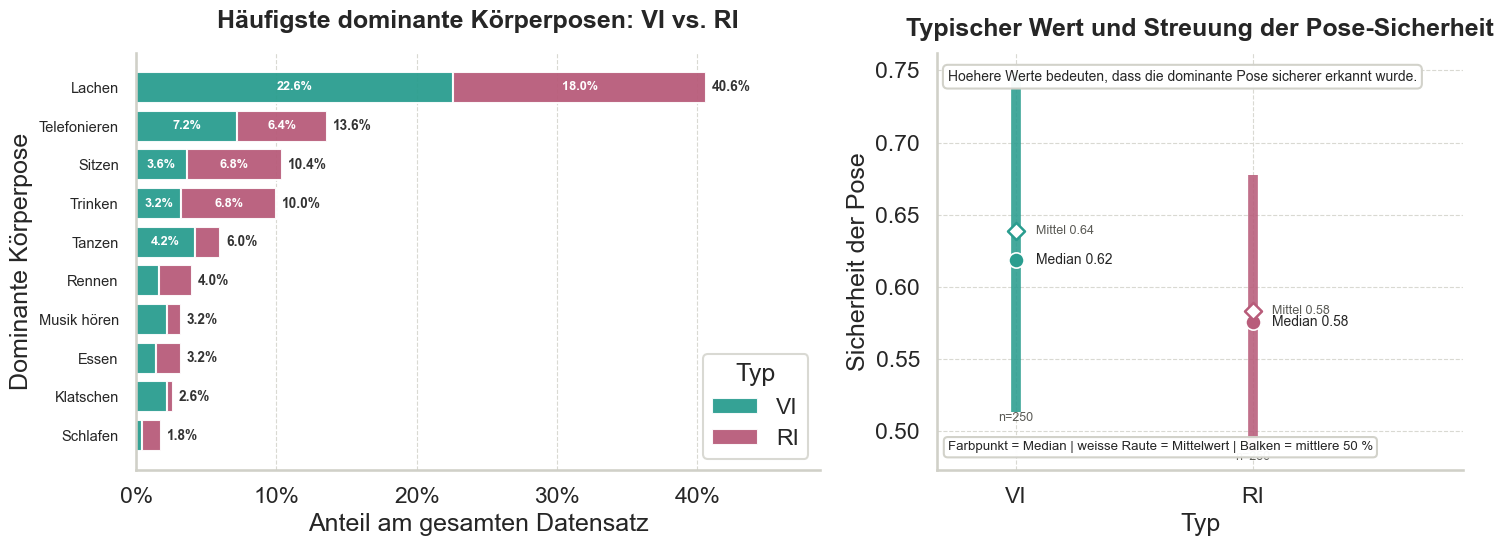

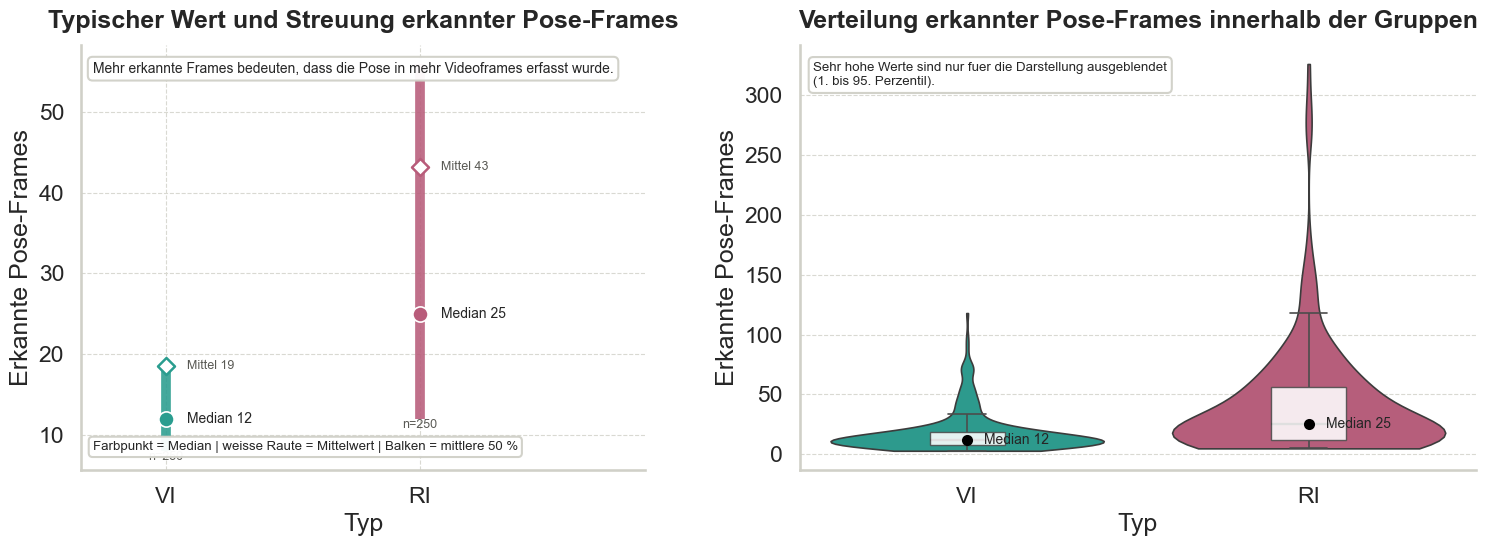

In [4]:
# Visualisierung der Körperhaltungen
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

PALETTE_COLOR = {'VI': '#2A9D8F', 'RI': '#B85C7A'}
ORDER = ['VI', 'RI']
POSE_LABEL_MAP_DE = {
    'Calling': 'Telefonieren',
    'Clapping': 'Klatschen',
    'Cycling': 'Fahrradfahren',
    'Dancing': 'Tanzen',
    'Drinking': 'Trinken',
    'Eating': 'Essen',
    'Fighting': 'Kämpfen',
    'Hugging': 'Umarmen',
    'Laughing': 'Lachen',
    'Listening To Music': 'Musik hören',
    'Running': 'Rennen',
    'Sitting': 'Sitzen',
    'Sleeping': 'Schlafen',
    'Texting': 'Texten',
    'Using Laptop': 'Laptop nutzen',
    'Front': 'Vorne',
    'Side': 'Seite',
    'Back': 'Rücken',
    'Unbestimmt': 'Unbestimmt',
}

plot_label_map = {
    'pose_confidence': 'Sicherheit der Pose',
    'detected_pose_frames': 'Erkannte Pose-Frames',
}
plot_note_map = {
    'pose_confidence': 'Höhere Werte bedeuten, dass die dominante Pose sicherer erkannt wurde.',
    'detected_pose_frames': 'Mehr erkannte Frames bedeuten, dass die Pose in mehr Videoframes erfasst wurde.',
}
value_fmt = {
    'pose_confidence': '{:.2f}',
    'detected_pose_frames': '{:.0f}',
}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'VI', 'real': 'RI'}).fillna(df_plot['influencer_type'])
df_plot['pose_label_de'] = df_plot['pose_orientation_readable'].replace(POSE_LABEL_MAP_DE).fillna('Unbestimmt')

cat_df = df_plot[['typ', 'pose_label_de']].dropna().copy()
pose_counts = (
    cat_df.groupby(['pose_label_de', 'typ']).size().unstack(fill_value=0).reindex(columns=ORDER, fill_value=0)
)
total_pose_count = int(pose_counts[ORDER].to_numpy().sum())
if total_pose_count == 0:
    raise ValueError('Keine gültigen dominanten Körperposen für VI und RI gefunden.')
pose_counts['gesamt'] = pose_counts[ORDER].sum(axis=1)
pose_counts = pose_counts.sort_values('gesamt', ascending=True)
pose_shares = pose_counts[ORDER].div(total_pose_count)
pose_shares['gesamt'] = pose_shares[ORDER].sum(axis=1)
pose_order = pose_shares.index.tolist()

fig_height = max(7.2, 0.48 * len(pose_order) + 1.8)
fig, axes = plt.subplots(1, 2, figsize=(16.2, fig_height), gridspec_kw={'width_ratios': [1.4, 1.0]})
y_pos = np.arange(len(pose_order))
axes[0].barh(y_pos, pose_shares['VI'], color=PALETTE_COLOR['VI'], alpha=0.95, label='VI')
axes[0].barh(y_pos, pose_shares['RI'], left=pose_shares['VI'], color=PALETTE_COLOR['RI'], alpha=0.95, label='RI')
axes[0].set_title('Verteilung aller dominanten Körperposen: VI vs. RI', pad=18, weight='semibold')
axes[0].set_xlabel('Anteil am gesamten Datensatz')
axes[0].set_ylabel('Dominante Körperpose')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(pose_order, fontsize=10.5)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].grid(axis='y', visible=False)
axes[0].legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='lower right')
max_pose_share = float(pose_shares['gesamt'].max())
axes[0].set_xlim(0, max_pose_share * 1.20)

for i, (_, row) in enumerate(pose_shares.iterrows()):
    vi_share = row['VI']
    ri_share = row['RI']
    total_share = row['gesamt']

    if vi_share >= 0.03:
        axes[0].text(vi_share / 2, i, f'{vi_share:.1%}', ha='center', va='center', fontsize=9.2, color='white', weight='semibold')
    if ri_share >= 0.03:
        axes[0].text(vi_share + ri_share / 2, i, f'{ri_share:.1%}', ha='center', va='center', fontsize=9.2, color='white', weight='semibold')

    # Rechts steht der Gesamtanteil der Pose an allen gültigen Videos.
    axes[0].text(total_share + 0.004, i, f'{total_share:.1%}', ha='left', va='center', fontsize=9.8, color='#333333', weight='semibold')

metric_df = df_plot[['typ', 'pose_confidence']].dropna().copy()
display_df = metric_df.copy()
if len(display_df) >= 10:
    lower = display_df['pose_confidence'].quantile(0.01)
    upper = display_df['pose_confidence'].quantile(0.95)
    display_df = display_df[display_df['pose_confidence'].between(lower, upper)]
summary = metric_df.groupby('typ')['pose_confidence'].agg(
    q1=lambda x: x.quantile(0.25), median='median', q3=lambda x: x.quantile(0.75), mean='mean', n='count'
).reindex(ORDER)
x_positions = np.array([0.00, 0.36])
for pos, grp in zip(x_positions, ORDER):
    if grp not in summary.index or pd.isna(summary.loc[grp, 'median']):
        continue
    color = PALETTE_COLOR[grp]
    q1 = summary.loc[grp, 'q1']; med = summary.loc[grp, 'median']; q3 = summary.loc[grp, 'q3']; mean = summary.loc[grp, 'mean']; n_obs = int(summary.loc[grp, 'n'])
    axes[1].vlines(pos, q1, q3, color=color, linewidth=7, alpha=0.88, zorder=2)
    axes[1].scatter(pos, med, s=120, color=color, edgecolor='white', linewidth=1.2, zorder=3)
    axes[1].scatter(pos, mean, s=75, color='white', edgecolor=color, linewidth=1.8, marker='D', zorder=4)
    axes[1].text(pos + 0.03, med, f"Median {med:.2f}", va='center', ha='left', fontsize=10)
    axes[1].text(pos + 0.03, mean, f"Mittel {mean:.2f}", va='center', ha='left', fontsize=9, color='#5a5a55')
    axes[1].text(pos, q1, f"n={n_obs}", va='top', ha='center', fontsize=9, color='#5a5a55')
axes[1].set_xlim(-0.12, 0.68)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(ORDER)
axes[1].set_xlabel('Typ')
axes[1].set_ylabel('Sicherheit der Pose')
axes[1].set_title('Typischer Wert und Streuung der Pose-Sicherheit', pad=12, weight='semibold')
axes[1].text(
    0.02, 0.04,
    'Farbpunkt = Median | weisse Raute = Mittelwert | Balken = mittlere 50 %',
    transform=axes[1].transAxes, ha='left', va='bottom', fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
)
axes[1].text(
    0.02, 0.96,
    plot_note_map['pose_confidence'],
    transform=axes[1].transAxes, ha='left', va='top', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
)

for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.8), gridspec_kw={'width_ratios': [1.0, 1.2]})
for idx, metric in enumerate(['pose_confidence', 'detected_pose_frames']):
    metric_df = df_plot[['typ', metric]].dropna().copy()
    display_df = metric_df.copy()
    if len(display_df) >= 10:
        lower = display_df[metric].quantile(0.01)
        upper = display_df[metric].quantile(0.95)
        display_df = display_df[display_df[metric].between(lower, upper)]
    summary = metric_df.groupby('typ')[metric].agg(
        q1=lambda x: x.quantile(0.25), median='median', q3=lambda x: x.quantile(0.75), mean='mean', n='count'
    ).reindex(ORDER)
    ax_left = axes[0] if idx == 0 else None
    # Rechts Violin- und Boxplot, links ein reduzierter Vergleich für erkannte Frames
    if idx == 1:
        ax_left = axes[0]
        x_positions = np.array([0.00, 0.36])
        for pos, grp in zip(x_positions, ORDER):
            if grp not in summary.index or pd.isna(summary.loc[grp, 'median']):
                continue
            color = PALETTE_COLOR[grp]
            q1 = summary.loc[grp, 'q1']; med = summary.loc[grp, 'median']; q3 = summary.loc[grp, 'q3']; mean = summary.loc[grp, 'mean']; n_obs = int(summary.loc[grp, 'n'])
            ax_left.vlines(pos, q1, q3, color=color, linewidth=7, alpha=0.88, zorder=2)
            ax_left.scatter(pos, med, s=120, color=color, edgecolor='white', linewidth=1.2, zorder=3)
            ax_left.scatter(pos, mean, s=75, color='white', edgecolor=color, linewidth=1.8, marker='D', zorder=4)
            ax_left.text(pos + 0.03, med, f"Median {mean if False else med:.0f}", va='center', ha='left', fontsize=10)
            ax_left.text(pos + 0.03, mean, f"Mittel {mean:.2f}" if metric != 'detected_pose_frames' else f"Mittel {mean:.0f}", va='center', ha='left', fontsize=9, color='#5a5a55')
            ax_left.text(pos, q1, f"n={n_obs}", va='top', ha='center', fontsize=9, color='#5a5a55')
        ax_left.set_xlim(-0.12, 0.68)
        ax_left.set_xticks(x_positions)
        ax_left.set_xticklabels(ORDER)
        ax_left.set_xlabel('Typ')
        ax_left.set_ylabel('Erkannte Pose-Frames')
        ax_left.set_title('Typischer Wert und Streuung erkannter Pose-Frames', pad=12, weight='semibold')
        ax_left.text(
            0.02, 0.04,
            'Farbpunkt = Median | weisse Raute = Mittelwert | Balken = mittlere 50 %',
            transform=ax_left.transAxes, ha='left', va='bottom', fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
        )
        ax_left.text(
            0.02, 0.96,
            plot_note_map['detected_pose_frames'],
            transform=ax_left.transAxes, ha='left', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
        )

sns.violinplot(
    data=df_plot[df_plot['typ'].isin(ORDER)].dropna(subset=['detected_pose_frames']),
    x='typ', y='detected_pose_frames', order=ORDER, hue='typ', dodge=False,
    palette=PALETTE_COLOR, inner=None, cut=0, linewidth=1.2, saturation=0.95,
    legend=False, ax=axes[1]
)
sns.boxplot(
    data=df_plot[df_plot['typ'].isin(ORDER)].dropna(subset=['detected_pose_frames']),
    x='typ', y='detected_pose_frames', order=ORDER, width=0.22, fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'zorder': 3}, whiskerprops={'linewidth': 1.2}, capprops={'linewidth': 1.2},
    medianprops={'color': 'black', 'linewidth': 1.7}, ax=axes[1]
)
medians = df_plot.groupby('typ')['detected_pose_frames'].median().reindex(ORDER)
for x_pos, grp in zip(range(len(ORDER)), ORDER):
    med_val = medians.get(grp)
    if pd.notna(med_val):
        axes[1].scatter(x_pos, med_val, c='black', s=42, zorder=5)
        axes[1].text(x_pos + 0.05, med_val, f'Median {med_val:.0f}', va='center', fontsize=10)
axes[1].set_title('Verteilung erkannter Pose-Frames innerhalb der Gruppen', pad=12, weight='semibold')
axes[1].set_xlabel('Typ')
axes[1].set_ylabel('Erkannte Pose-Frames')
axes[1].text(
    0.02, 0.96,
    'Sehr hohe Werte sind nur für die Darstellung ausgeblendet\n(1. bis 95. Perzentil).',
    transform=axes[1].transAxes, ha='left', va='top', fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
)
for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(); plt.show()



In [5]:
results = []
chi2_results = []

# H20: pose_label (kategorial) -> Chi²-Test
label_col = 'pose_orientation_readable' if 'pose_orientation_readable' in df.columns else 'pose_orientation'
if label_col in df.columns and 'influencer_type' in df.columns:
    tmp = df[[label_col, 'influencer_type']].dropna().copy()
    contingency = pd.crosstab(tmp[label_col], tmp['influencer_type'])
    if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
        chi2, p_val, dof, _ = chi2_contingency(contingency)
        chi2_results.append({'metric': label_col, 'test': 'Chi2', 'chi2': chi2, 'dof': dof, 'p_value': p_val, 'n': len(tmp)})

# H21: pose_confidence (metrisch) -> Mann-Whitney-U
metric = 'pose_confidence'
ai_vals = df.loc[df['influencer_type'] == 'ai', metric].dropna()
real_vals = df.loc[df['influencer_type'] == 'real', metric].dropna()
if len(ai_vals) > 0 and len(real_vals) > 0:
    u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
    results.append({
        'metric': metric,
        'test': 'Mann-Whitney-U',
        'n_ai': len(ai_vals),
        'n_real': len(real_vals),
        'mean_ai': ai_vals.mean(),
        'mean_real': real_vals.mean(),
        'median_ai': ai_vals.median(),
        'median_real': real_vals.median(),
        'u_stat': u_stat,
        'u_p': u_p,
    })

results_df = pd.DataFrame(results).round(4)
chi2_df = pd.DataFrame(chi2_results).round(4)
display(results_df)
display(chi2_df)


,metric,test,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,pose_confidence,Mann-Whitney-U,250,250,0.6387,0.583,0.6185,0.5756,36535.0,0.0011


,metric,test,chi2,dof,p_value,n
0,pose_orientation_readable,Chi2,42.8528,14,0.0001,500


In [6]:
# Zusammenhang zwischen Körperhaltung und Engagement-Rate
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)
sns.set_palette(['#4C78A8', '#F5855B'])
df_plot = df.copy(); df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}
LINESTYLE = {'KI': '-', 'Real': '--'}

corr_results=[]
anova_reg_results=[]

if 'video_engagement_rate' in df_plot.columns:
    metric_col='pose_confidence'
    metric_df = df_plot[['typ', metric_col, 'video_engagement_rate']].dropna().copy()
    rho, pval = spearmanr(metric_df[metric_col], metric_df['video_engagement_rate'], nan_policy='omit')
    corr_results.append({'Metrik': metric_col, 'Methode': 'Spearman', 'Spearman_rho': rho, 'p_Wert': pval})

    fig, ax = plt.subplots(figsize=(8.8, 6.1))
    stat_lines=[]
    for grp in ['KI', 'Real']:
        sub = metric_df[metric_df['typ'] == grp]
        if sub.empty:
            continue
        rho_grp, p_grp = spearmanr(sub[metric_col], sub['video_engagement_rate'], nan_policy='omit')
        stat_lines.append(f'{grp}: rho={rho_grp:.2f}')
        sns.scatterplot(data=sub, x=metric_col, y='video_engagement_rate', color=PALETTE_COLOR[grp], marker=MARKER[grp], edgecolor='white', linewidth=0.35, s=48, alpha=0.58, ax=ax, label=grp)
        sns.regplot(data=sub, x=metric_col, y='video_engagement_rate', scatter=False, ci=None, line_kws={'color': PALETTE_COLOR[grp], 'linewidth': 2.2, 'linestyle': LINESTYLE[grp]}, ax=ax)
    ax.set_title('Sicherheit der Pose und Engagement-Rate', pad=12, weight='semibold')
    ax.set_xlabel('Sicherheit der Pose')
    ax.set_ylabel('Engagement-Rate pro Video')
    ax.text(0.03, 0.97, '\n'.join(stat_lines), transform=ax.transAxes, ha='left', va='top', fontsize=10.5, bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.95))
    ax.text(0.03, 0.06, 'Linien zeigen den Trend innerhalb von KI bzw. Real.', transform=ax.transAxes, ha='left', va='bottom', fontsize=9.5, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.95))
    ax.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout(); plt.show()

    label_col = 'pose_orientation_readable' if 'pose_orientation_readable' in df_plot.columns else 'pose_orientation'
    analysis_df = df_plot[[label_col, 'video_engagement_rate']].dropna().copy()
    groups = [g['video_engagement_rate'].values for _, g in analysis_df.groupby(label_col) if len(g) > 1]
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        anova_reg_results.append({'Metrik': label_col, 'analysis': 'ANOVA', 'stat': f_stat, 'p_Wert': p_val, 'n': len(analysis_df)})

    X = pd.get_dummies(analysis_df[label_col], drop_first=True, dtype=float)
    if X.shape[1] > 0:
        X_mat = np.column_stack([np.ones(len(X)), X.values])
        y = analysis_df['video_engagement_rate'].values.astype(float)
        beta, *_ = np.linalg.lstsq(X_mat, y, rcond=None)
        y_hat = X_mat @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = np.nan if ss_tot == 0 else 1 - (ss_res / ss_tot)
        anova_reg_results.append({'Metrik': label_col, 'analysis': 'Dummy-Regression', 'R2': r2, 'n': len(analysis_df), 'k_dummies': X.shape[1]})

corr_df = pd.DataFrame(corr_results).round(4)
anova_reg_df = pd.DataFrame(anova_reg_results).round(4)
display(corr_df)
display(anova_reg_df)



IndentationError: expected an indented block after 'for' statement on line 36 (1428378558.py, line 37)

In [7]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    mean_diff = row['mean_ai'] - row['mean_real']
    direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Unterschied')
    print(f"- Sicherheit der Pose (Mann-Whitney): {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Höhere Werte bedeuten, dass die dominante Pose sicherer erkannt wurde ({direction}).")

if 'chi2_df' in globals() and not chi2_df.empty:
    row = chi2_df.iloc[0]
    print(f"- Dominante Koerperhaltung (Chi²): {sig_label(row['p_value'])} (chi2={row['chi2']:.2f}, p={row['p_value']:.4f}). Interpretation: Koerperhaltungen treten in KI und Real unterschiedlich haeufig auf.")

if 'corr_df' in globals() and not corr_df.empty:
    row = corr_df.iloc[0]
    rho = row['Spearman_rho']; p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    print(f"- Engagement ~ Sicherheit der Pose (Spearman): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang mit Engagement.")

if 'anova_reg_df' in globals() and not anova_reg_df.empty:
    for _, row in anova_reg_df.iterrows():
        if row['analysis'] == 'ANOVA':
            print(f"- Engagement ~ dominante Koerperhaltung (ANOVA): {sig_label(row['p_Wert'])} (F={row['stat']:.2f}, p={row['p_Wert']:.4f}).")
        else:
            print(f"- Engagement ~ dominante Koerperhaltung (Dummy-Regression): R²={row['R2']:.3f} (erklaerte Varianz).")



Kurzinterpretation:
- Pose Confidence (Mann-Whitney): signifikant (p=0.0011). Interpretation: Positiver Zusammenhang zeigt Einfluss von Bewegungsdynamik (höher bei KI).
- Pose Label (Chi²): signifikant (chi2=42.85, p=0.0001). Interpretation: Körperposen treten je Gruppe unterschiedlich häufig auf.
- Engagement ~ pose_confidence (Spearman): nicht signifikant (rho=-0.083, p=0.0653). Interpretation: negativer Zusammenhang mit Engagement.
- Engagement ~ pose_label (ANOVA): signifikant (F=2.04, p=0.0138).
- Engagement ~ pose_label (Dummy-Regression): R²=0.056 (erklaerte Varianz).
